In [1]:
MODEL_CLS = "cfnet"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{DATASET}/{MODEL_CLS}_{STRATEGY}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\03_RS-DeepCF


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
import yaml
from recsys import config, experiment, deepcf

In [6]:
kwargs = dict(
    file=PATH_CONFIG_FILE,
    mode="r",
    encoding="utf-8",
)
with open(**kwargs) as f:
    cfg = yaml.safe_load(f)

In [7]:
experiment_cfg = config.parser.experiment.experiment(cfg)
schema_cfg = config.parser.experiment.schema(cfg)
pipeline_cfg = config.parser.experiment.pipeline(cfg)
trainer_cfg = config.parser.experiment.trainer(cfg)
evaluator_cfg = config.parser.experiment.evaluator(cfg)
model_cfg = config.parser.model.auto(cfg)

In [8]:
experiment.utils.seed.reset(experiment_cfg)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{experiment_cfg.data}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    cfg=schema_cfg,
    percentaile=0.9,
)

experiment.utils.data_handler.description(**kwargs)

number of user: 609
number of item: 8452
total interaction: 81763
interaction density: 1.5885 %
max interaction of user: 2117
max interaction of item: 315
top 10.0 % interaction of user: 344.4
top 10.0 % interaction of item: 25.0
mean interaction of user: 134
mean interaction of item: 9


In [11]:
kwargs = dict(
    df=df,
    cfg=pipeline_cfg,
)

dataloaders, interactions, histories = experiment.pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [12]:
kwargs = dict(
    interactions=interactions,
    cfg=model_cfg.rlnet,
)    

rlnet_module = deepcf.rlnet.Module(**kwargs)

In [13]:
kwargs = dict(
    interactions=interactions,
    cfg=model_cfg.mlnet,
)    

mlnet_module = deepcf.mlnet.Module(**kwargs)

In [14]:
kwargs = dict(
    rlnet=rlnet_module,
    mlnet=mlnet_module,
)

model = deepcf.cfnet.Module(**kwargs)

# Train

In [15]:
kwargs = dict(
    model=model,
    cfg=trainer_cfg,
)

trainer = experiment.trainer.builder.trainer_builder(**kwargs)

In [16]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
    dev_loader=dataloaders["dev"],
)

record = trainer.fit(**kwargs)

DEVELOPMENT
	BEST SCORE: 0.5653
	BEST EPOCH: 12


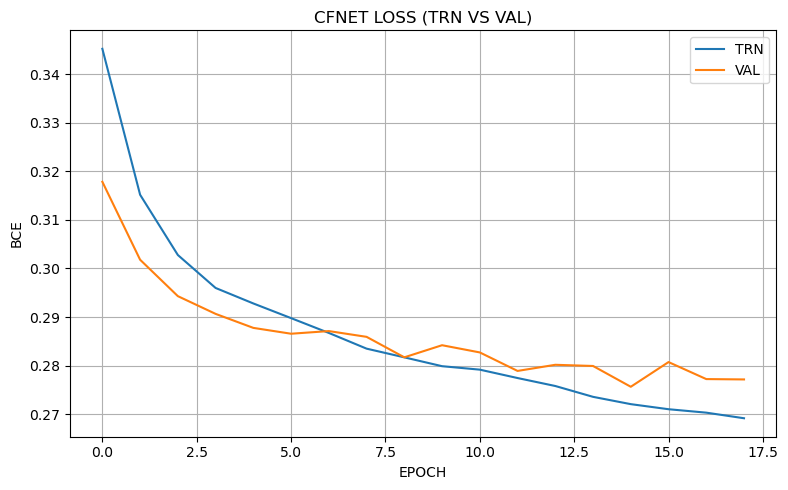

In [17]:
kwargs = dict(
    records=[record["trn"], record["val"]],
    labels=["TRN", "VAL"],
    criterion="BCE",
    title="CFNET LOSS (TRN VS VAL)"
)

experiment.utils.visualizer.compare_curve(**kwargs)

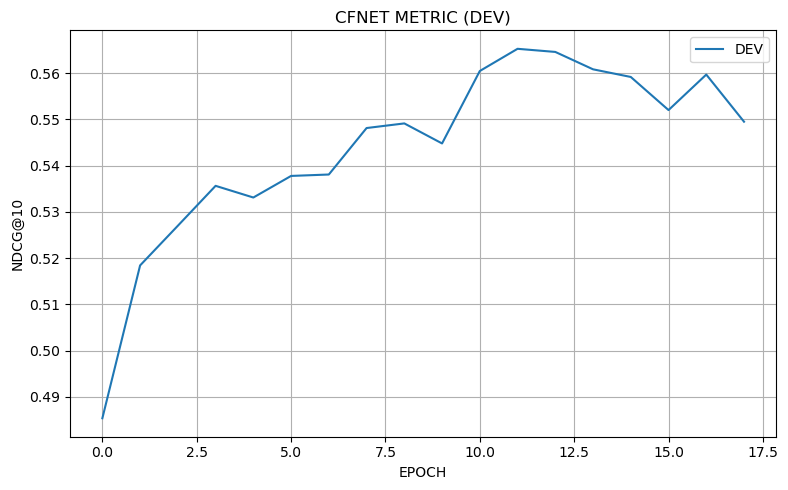

In [18]:
kwargs = dict(
    record=record["dev"],
    label="DEV",
    criterion="NDCG@10",
    title="CFNET METRIC (DEV)",
)

experiment.utils.visualizer.criterion_curve(**kwargs)

# Test

In [19]:
kwargs = dict(
    model=model,
    cfg=evaluator_cfg,
)

evaluator = experiment.evaluator.builder.evaluator_builder(**kwargs)

In [20]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3172/3172 [00:08<00:00, 359.58it/s]


In [21]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.837171,0.362829,0.324702,0.233742,0.443332
1,10,0.939145,0.281579,0.463240,0.284313,0.467570
2,15,0.960526,0.231579,0.536805,0.305908,0.483502
3,20,0.975329,0.197122,0.575456,0.315272,0.491692
4,25,0.991776,0.177368,0.623158,0.324501,0.505870
5,50,0.998355,0.118651,0.731821,0.343049,0.539789


# Save

In [22]:
PATH = f'./checkpoints/{experiment_cfg.data}/{experiment_cfg.model}_{experiment_cfg.strategy}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

experiment.utils.checkpointer.save(**kwargs)